# (연구) HST example 1
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [기하학적 딥러닝, 논문연구]

### Import

In [2]:
import heavysnow as hs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybase as pb
import rpy2 
%load_ext rpy2.ipython

### Data 

In [18]:
f=np.array([-1,-1,-1,-1,1,-1,-1,-1,-1,1,1,1,1,-1,1,1,1,1])*1.0
n=len(f)
V=list(range(n))
W=np.zeros([n,n])
for i in range(n):
    for j in range(n):
        if abs(i-j)==1: W[i,j]=1
W[0,0]=1
W[n-1,n-1]=1

In [19]:
gs1=hs.GraphSignal(V,W,f)

### HST

In [20]:
# hst1=hs.HeavySnowTransform(gs1)
# hst2=hs.HeavySnowTransform(gs1)
# hst3=hs.HeavySnowTransform(gs1)
# hst4=hs.HeavySnowTransform(gs1)
# hst5=hs.HeavySnowTransform(gs1)
# hst6=hs.HeavySnowTransform(gs1)
# hst7=hs.HeavySnowTransform(gs1)
hst8=hs.HeavySnowTransform(gs1)

# hst1.snow(tau=10,b=0.03)
# hst2.snow(tau=50,b=0.03)
# hst3.snow(tau=100,b=0.03)
# hst4.snow(tau=500,b=0.03)
# hst5.snow(tau=1000,b=0.03)
# hst6.snow(tau=5000,b=0.03)
# hst7.snow(tau=10000,b=0.03)
hst8.snow(tau=16000,b=0.03)

HST (tau= 16000, b=0.03)
16000/16000
HST completed and all history is recorded.


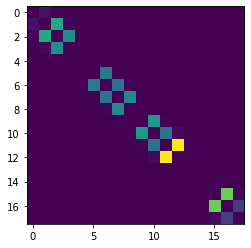

In [21]:
plt.imshow(hst8.snowweight)

### 시각화를 위해서 R로 자료를 옮김

In [22]:
pb.push(hst8.tau,"maxtau")
pb.push(hst8.graphweight,"W_Graph")
pb.push(hst8.euclidweight,"W_Euclid")
pb.push(hst8.snowweight,"W_HST")
pb.push(hst8.V,"V")
pb.push(hst8.f,"f")
pb.push(hst8.n,"n")

### R을 활용한 시각화 (1): 원래자료 

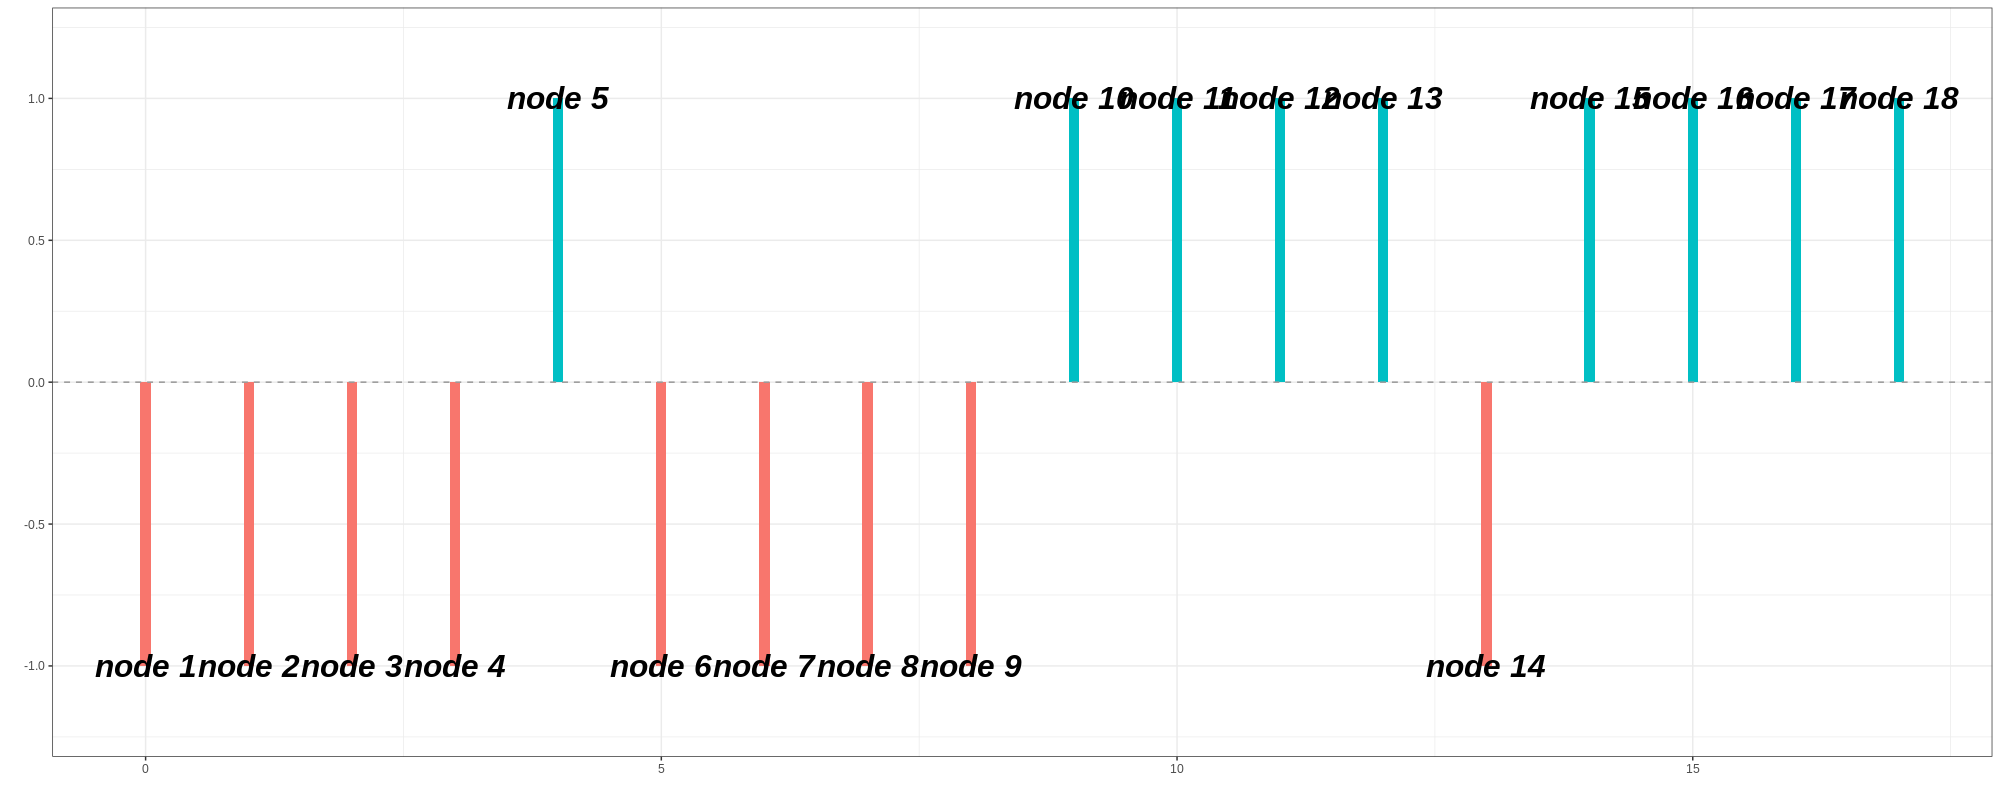

In [23]:
%%R -w 2000 -h 800 -r 100
library(tidyverse)
library(latex2exp)
library(gridExtra)
source('rbase.R')
Vtext=str_c('node ',V+1)
fig0<-ggplot(data=tibble(V=V,f=f,Vtext=Vtext),aes(x=V,y=f,label=Vtext))+
geom_col(aes(fill=(f>0)),width=0.1)+geom_hline(aes(yintercept=0),col="gray60",lty=2)+
geom_text(fontface = 4,size=8)+
xlab("")+ylab("")+guides(fill=FALSE)+theme(plot.title=element_text(face="bold.italic"))+theme_bw()+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 15, color = "black", face = "bold.italic"))+
ylim(-1.2,1.2)+
theme(plot.title=element_text(face="bold.italic"))
#ggsave(plot=p0,"./fig/2021-0217_fig0.pdf",width=20,height=6)
fig0

### R을 활용한 시각화 (2): Weight matrix 와 Eigen plot 

`-` `ggplot`에서 `geom_tile`을 사용하기 위해서 매트릭스 형태인 `W_Graph`, `W_Euclid`, `W_HST`를 길게 펼친다. 결과를 각각 `W_Graph_long`, `W_Euclid_long`, `W_HST_long`에 저장한다. 

In [24]:
%%R
grid<-expand.grid(x=1:n,y=1:n)
W_Graph_long<-as_tibble(cbind(grid,as.vector(W_Graph)));names(W_Graph_long)<-c("x","y","W")
W_Euclid_long<-as_tibble(cbind(grid,as.vector(W_Euclid)));names(W_Euclid_long)<-c("x","y","W")
W_HST_long<-as_tibble(cbind(grid,as.vector(W_HST)));names(W_HST_long)<-c("x","y","W")

`-` 그래프퓨리에 변환: $(\bf{f},\bf{W})$에 그래프 퓨리에 변환을 수행함.  

In [25]:
%%R
source('heavysnow.R')
gfftrslt_Euclid<-gfft(f,W_Euclid)
gfftrslt_Graph<-gfft(f,W_Graph)
gfftrslt_HST<-gfft(f,W_HST)

`-` 그래프 퓨리에 변환의 결과 고유치, 고유벡터, $\bf{\bar{f}}$가 반환됨. 

In [26]:
%%R
head(gfftrslt_HST)

$λ
 [1] 1.978549e+00 1.965891e+00 1.959991e+00 1.945525e+00 1.654130e+00
 [6] 1.536031e+00 1.038901e+00 1.031024e+00 4.854208e-01 3.799786e-01
[11] 2.345188e-02 1.108333e-03 7.739251e-08 5.323507e-09 1.750612e-13
[16] 8.703240e-18 4.455438e-18 4.472097e-20

$Ψ
               [,1]          [,2]          [,3]          [,4]          [,5]
 [1,] -5.516413e-12  2.442827e-21  4.158134e-25  3.706656e-05 -3.839556e-22
 [2,]  7.635924e-08  5.320375e-24  1.011592e-27 -5.132071e-01 -8.987575e-25
 [3,] -1.100164e-07  7.436846e-24  1.310005e-27  7.127889e-01 -1.246587e-24
 [4,]  6.772908e-08  4.895932e-24  9.552823e-28 -4.780695e-01 -8.265047e-25
 [5,]  1.600759e-39 -8.751627e-17 -2.404478e-17  2.853131e-46 -5.262766e-17
 [6,]  4.016224e-01 -1.141529e-18 -4.480855e-23  4.619891e-08  6.726318e-20
 [7,] -5.599928e-01 -1.522685e-18 -7.359992e-23 -7.998466e-08  8.757935e-20
 [8,]  5.838982e-01 -1.598906e-18 -8.376707e-23  9.509223e-08  9.251048e-20
 [9,] -4.291507e-01 -1.271169e-18 -5.761090e-23 -7.2506

`-` 시각화코드 

TableGrob (2 x 3) "arrange": 6 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (1-1,2-2) arrange gtable[layout]
3 3 (1-1,3-3) arrange gtable[layout]
4 4 (2-2,1-1) arrange gtable[layout]
5 5 (2-2,2-2) arrange gtable[layout]
6 6 (2-2,3-3) arrange gtable[layout]


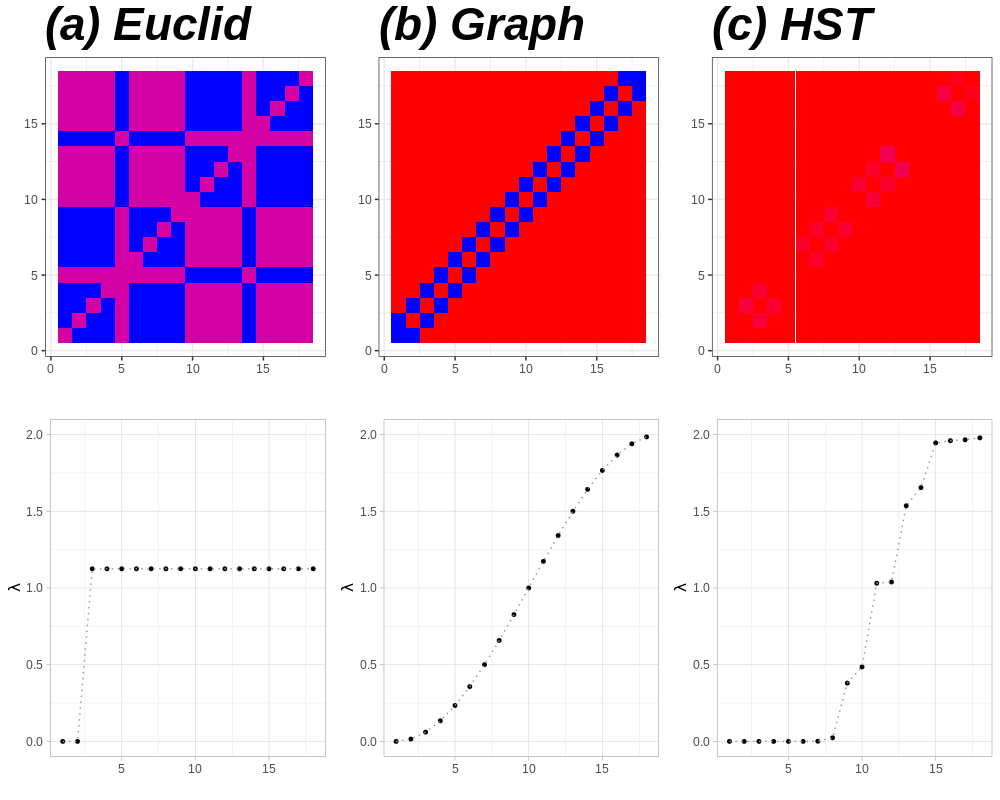

In [27]:
%%R -w 1000 -h 800 -r 100
library(gridExtra)

fig1_1<-ggplot()+geom_tile(data=W_Euclid_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
scale_fill_gradient2(low="red",high="blue",mid="purple",midpoint=0.25,breaks=c(0,0.5,0.99))+
labs(fill=TeX('$W$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(a) Euclid")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

fig1_2<-ggplot()+geom_tile(data=W_Graph_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
scale_fill_gradient2(low="red",high="blue",mid="purple",midpoint=0.5,breaks=c(0,0.5,0.99))+
labs(fill=TeX('$\\hat{W}$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(b) Graph")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

fig1_3<-ggplot()+geom_tile(data=W_HST_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
scale_fill_gradient2(low="red",high="blue",mid="purple",midpoint=0.5,breaks=c(0,0.5,0.99))+
labs(fill=TeX('$\\hat{W}(\\tau)$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(c) HST")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

fig1_4<-eigenplot(gfftrslt_Euclid)+ylim(0,2)+theme_light()
fig1_5<-eigenplot(gfftrslt_Graph)+ylim(0,2)+theme_light()
fig1_6<-eigenplot(gfftrslt_HST)+ylim(0,2)+theme_light()
fig1=grid.arrange(fig1_1,fig1_2,fig1_3,fig1_4,fig1_5,fig1_6,ncol=3,nrow=2)
fig1
#ggsave(plot=grid.arrange(p1_a,p1_b,p1_c,ncol=3),"2021-07-22_fig1.png",width=20,height=4)

### R을 활용한 시각화 (3): Decomposition 

`-` 디콤포지션을 수행하고 결과를 저장: $(\bf{f},\bf{W})$에 decomposition을 수행하고 그 결과를 각각 `decomprslt_Euclid`, `decomprslt_Graph`, `decomprslt_HST`에 저장한다. 

In [28]:
%%R 
decomprslt_Euclid<-decompose(f,W_Euclid,V=1:n) # 0, 35000, 60000, 80000
decomprslt_Graph<-decompose(f,W_Graph,V=1:n) # 0, 35000, 60000, 80000
decomprslt_HST<-decompose(f,W_HST,V=1:n) # 0, 35000, 60000, 80000

`-` 디콤포지션 결과는 아래와 같은 형태임 

In [29]:
%%R
head(decomprslt_Euclid)

# A tibble: 6 x 5
      V Vindex eigenvectorindex  fhat eigenvalue
  <int>  <int>            <dbl> <dbl>      <dbl>
1     1      1                1 -1      6.59e-17
2     2      2                1 -1.00   6.59e-17
3     3      3                1 -1      6.59e-17
4     4      4                1 -1      6.59e-17
5     5      5                1  0      6.59e-17
6     6      6                1 -1.00   6.59e-17


In [30]:
%%R 
decomprslt_Euclid$method="Euclid"
decomprslt_Graph$method="Graph"
decomprslt_HST$method="HST"
decomprslt<-rbind(decomprslt_Euclid,decomprslt_Graph,decomprslt_HST)

`-` 디콤포지션결과를 시각화한다. `geom_col`과 `facet_grid`를 이용. 

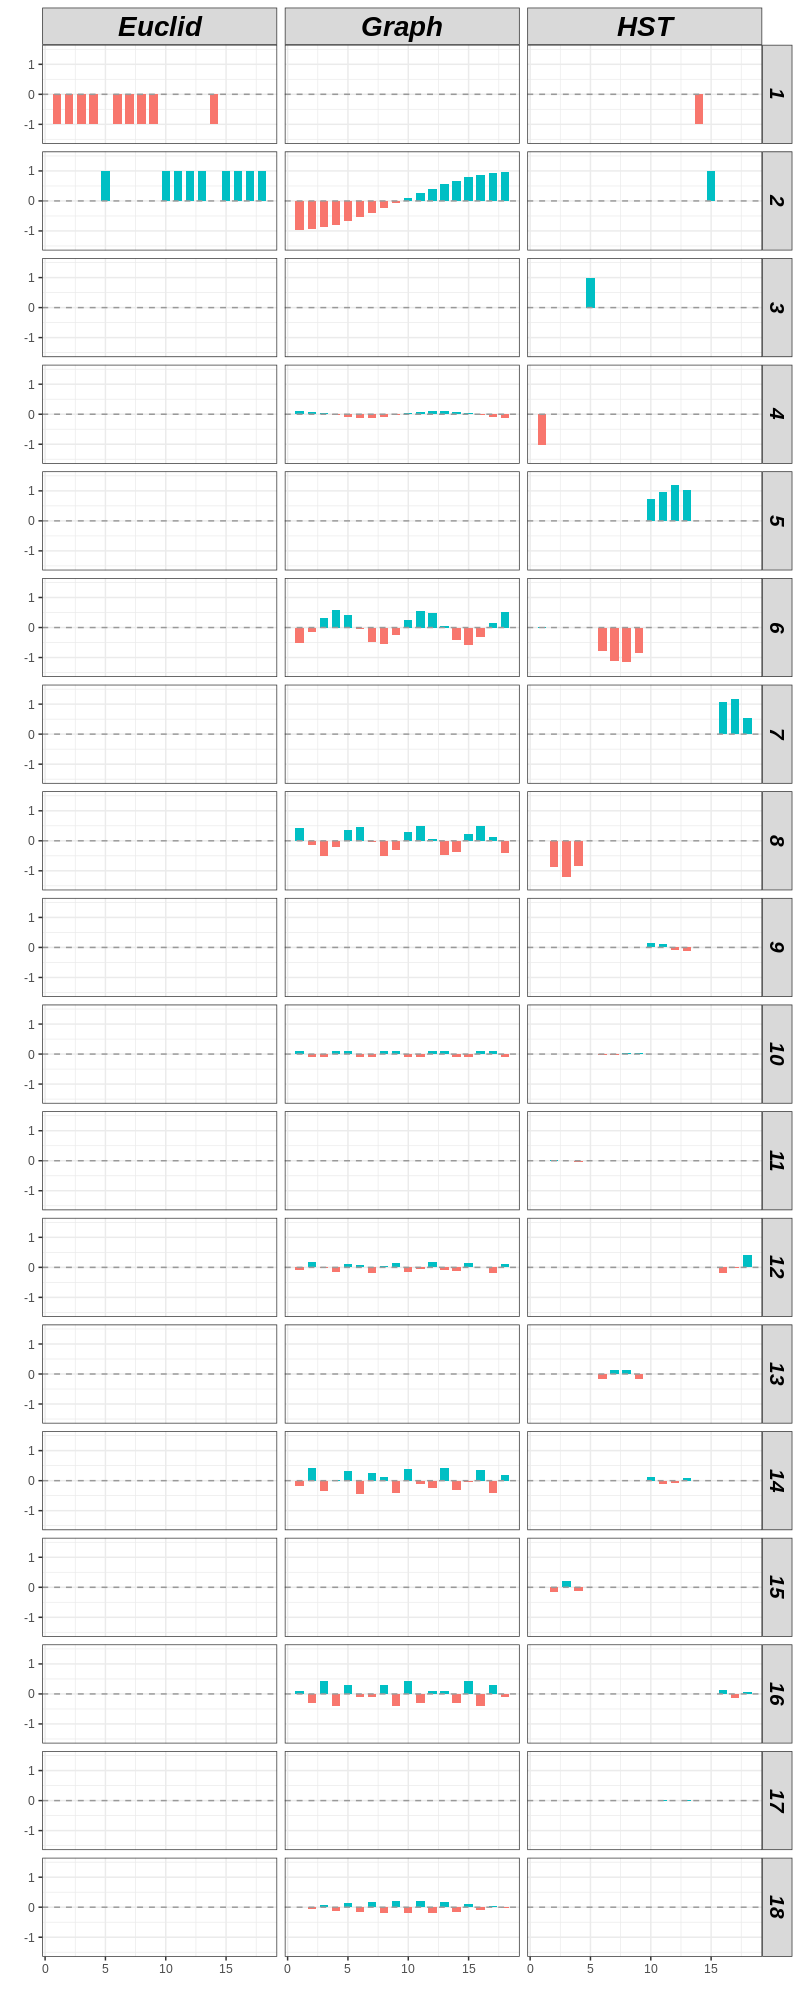

In [31]:
%%R -w 800 -h 2000 -r 100
fig2<-ggplot(data=decomprslt,aes(x=V,y=fhat))+
geom_col(aes(fill=fhat>0),width=0.7)+facet_grid(eigenvectorindex~method)+geom_hline(aes(yintercept=0),col="gray60",lty=2)+
xlab("")+ylab("")+guides(fill=FALSE)+theme(plot.title=element_text(face="bold.italic"))+theme_bw()+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 15, color = "black", face = "bold.italic"))+
ylim(-1.5,1.5)+
theme(plot.title=element_text(face="bold.italic"))
fig2
#ggsave(plot=fig2,"./fig/2021-0514_fig2.pdf",width=20,height=6)